In [85]:
import numpy as np

In [86]:
def generate_dataset(n_samples=300):
    np.random.seed(42)

    X = []
    y = []

    # Class 0
    X0 = np.random.randn(n_samples, 2) + np.array([0, 0])
    y0 = np.zeros(n_samples)

    # Class 1
    X1 = np.random.randn(n_samples, 2) + np.array([5, 5])
    y1 = np.ones(n_samples)

    # Class 2
    X2 = np.random.randn(n_samples, 2) + np.array([0, 5])
    y2 = np.full(n_samples, 2)

    X = np.vstack([X0, X1, X2])
    y = np.concatenate([y0, y1, y2])

    return X, y.astype(int)

X, y = generate_dataset()

In [87]:
def compute_scores(X, theta):
    score = np.dot(X,theta)    
    return score

In [88]:
def softmax_function(score):
    score = score - np.max(score, axis=1, keepdims=True)
    return np.exp(score)/ np.sum(np.exp(score),axis=1, keepdims=True)

In [89]:
def predict(probs):
    index = np.argmax(probs,axis=1)
    return index

In [90]:
def onehot(y):    
    encoded  = np.zeros((len(y), len(np.unique(y))))
    encoded[np.arange(len(y)), y] = 1
    return encoded

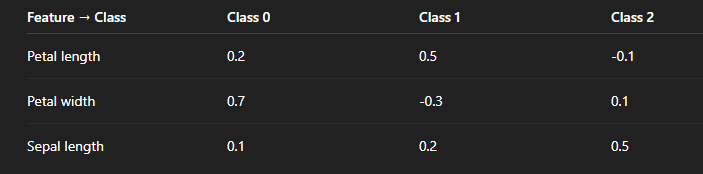

In [ ]:
m,n = X.shape[1], len(np.unique(y))
Theta = np.ones((m,n))

Defining the initial theta which has to be modified with the help of gradient descent

In [92]:
Theta

array([[1., 1., 1.],
       [1., 1., 1.]])

In [93]:
import matplotlib.pyplot as plt

Loss: 1.0082855728524611
Early stopping at epoch:  17


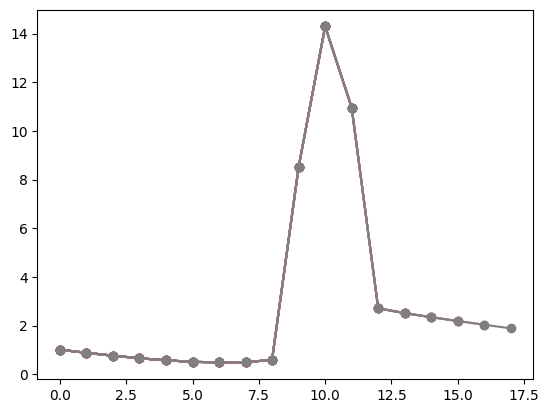

In [ ]:
epochs  = 1000
errors = []
minimum = None
best_loss = float('inf')
counter = 0
for i in range(epochs):
    answer = y
    one_hot_y = onehot(y)
    scores  = compute_scores(X, Theta)
    probs = softmax_function(scores)
    predicted = predict(probs)

    loss = -np.mean(np.sum(one_hot_y * np.log(probs), axis=1))    
    errors.append(loss)

    grad = (1/m) * X.T @ (probs - one_hot_y)
    
    Theta = Theta - 0.01 * grad

    if i % 100 == 0:
        print("Loss:", loss)
    plt.plot(errors,marker='o', linestyle='-')

    if loss < best_loss:
        best_loss = loss
        counter = 0
    else:
        counter += 1
    if counter == 10:
        print("Early stopping at epoch: ", i)
        break
    
    


In [103]:
max(errors)

np.float64(1.14)